<a href="https://colab.research.google.com/github/Suleiman17/House_Prediction_Model/blob/housePrediction/ML_FinalProj.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Library Imports

Import all necessary python libraries for:

- Data manipulation (pandas, numpy)

- Data visualization (matplotlib, seaborn)

- Machine learning models (sklearn, xgboost)

- Preprocessing tools (LabelEncoder, StandardScaler)

- Performance evaluation (mean_squared_error, accuracy_score, etc.)



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


# 2. Load and Preprocess Data

Loads the dataset.

Removes the details column (textual/unstructured).

Checks for missing values.

Encodes categorical features numerically.



In [ ]:
df = pd.read_csv("/SA_Aqar.csv")
df = df.drop(columns=["details"])

# Check for missing values
print("Missing values:\n", df.isnull().sum())

# Encode categorical features
for col in ["city", "district", "front"]:
    df[col] = LabelEncoder().fit_transform(df[col])

Missing values:
 city            0
district        0
front           0
size            0
property_age    0
bedrooms        0
bathrooms       0
livingrooms     0
kitchen         0
garage          0
driver_room     0
maid_room       0
furnished       0
ac              0
roof            0
pool            0
frontyard       0
basement        0
duplex          0
stairs          0
elevator        0
fireplace       0
price           0
dtype: int64


# 3. Exploratory Data Analysis (EDA)

Summarizes data statistics.

Visualizes price distribution.

Generates a correlation heatmap to see linear relationships.

Uses pairplots to view variable relationships with price.


Summary Statistics:
               city     district        front          size  property_age  \
count  3718.000000  3718.000000  3718.000000   3718.000000   3718.000000   
mean      1.473373    83.204680     5.479290    390.968531      5.064820   
std       1.119070    46.515937     2.420648   1565.056135      7.590427   
min       0.000000     0.000000     0.000000      1.000000      0.000000   
25%       0.000000    46.000000     4.000000    280.000000      0.000000   
50%       1.000000    79.000000     6.000000    330.000000      2.000000   
75%       2.000000   117.000000     7.000000    400.000000      7.000000   
max       3.000000   173.000000     9.000000  95000.000000     36.000000   

          bedrooms    bathrooms  livingrooms      kitchen       garage  ...  \
count  3718.000000  3718.000000  3718.000000  3718.000000  3718.000000  ...   
mean      5.083916     4.606509     2.243948     0.909360     0.802044  ...   
std       1.230040     0.703449     0.916436     0.28713

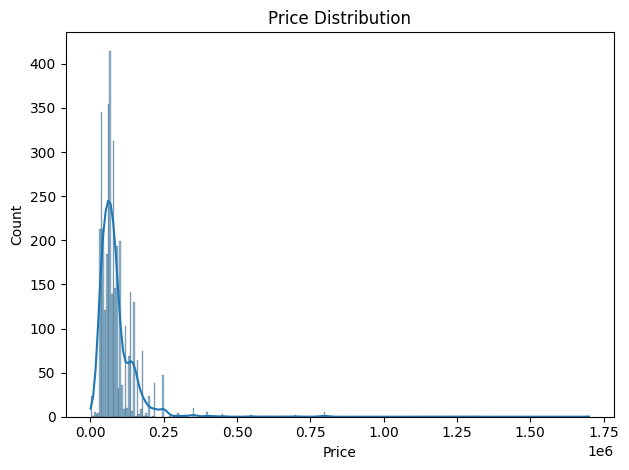

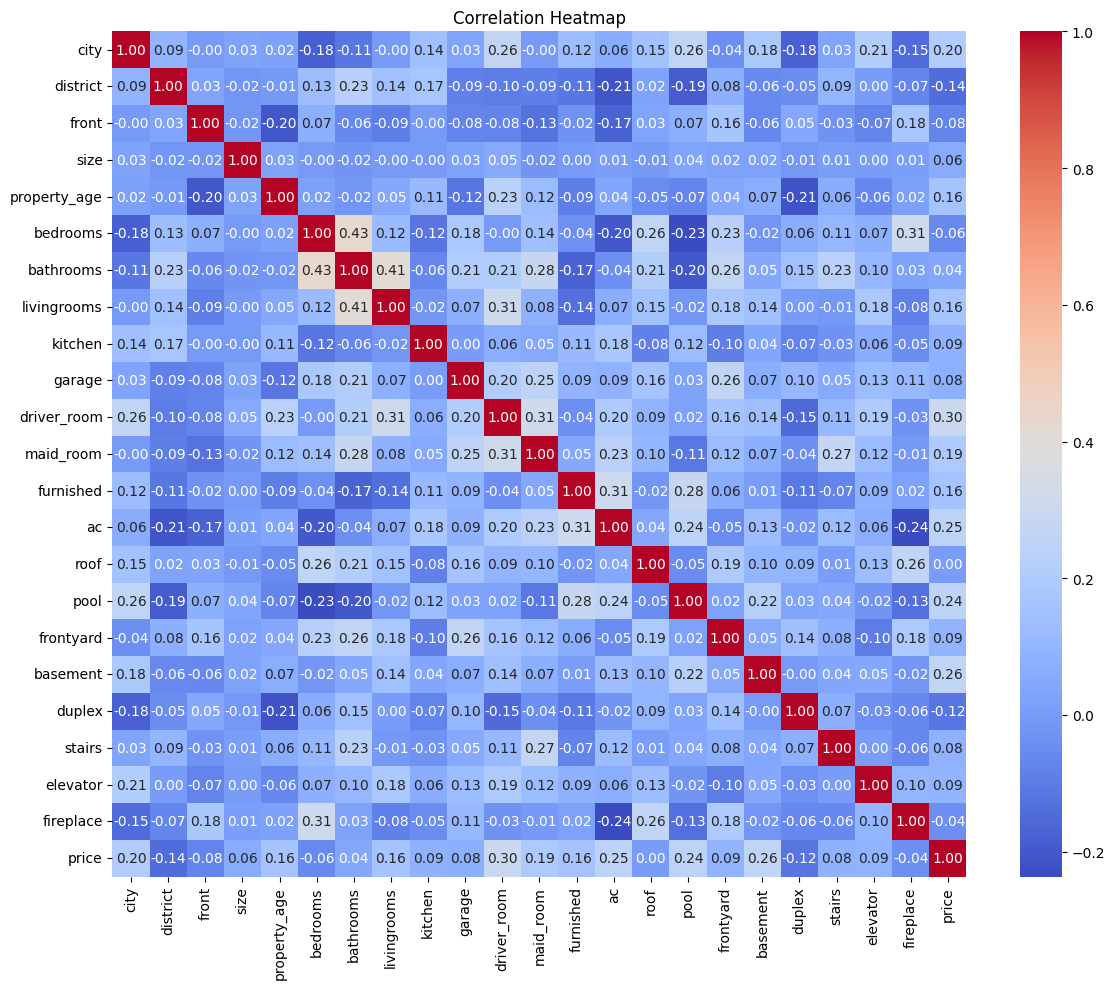

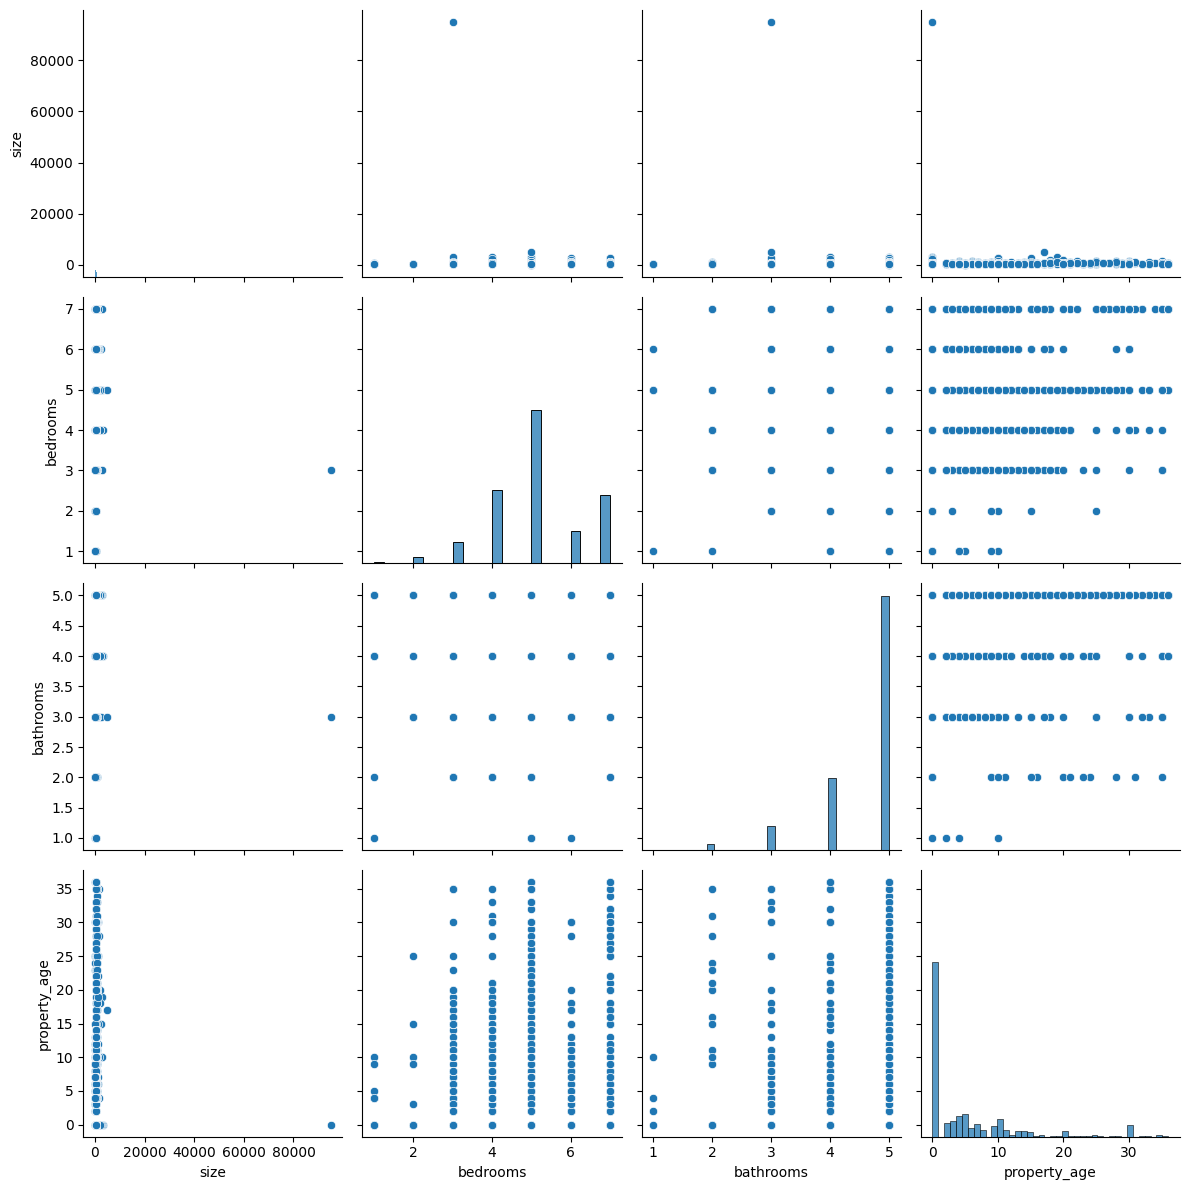

In [ ]:
print("\nSummary Statistics:\n", df.describe())

# Target distribution
plt.figure()
sns.histplot(df["price"], kde=True)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.tight_layout()
plt.show()

# Correlation heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

# Pairplot
sns.pairplot(df, vars=["size", "bedrooms", "bathrooms", "property_age"], y_vars=["price"], height=3)
plt.tight_layout()
plt.show()

# 4. Outlier Removal

Removes the top 1% most expensive homes to reduce model distortion from outliers.

In [ ]:
price_99 = df["price"].quantile(0.99)
df = df[df["price"] <= price_99]

# 5. Feature and Target Definition

- Defines X as features, y_reg as the target for regression, and y_clf for classification.

- Splits the data into training and testing sets (80/20 split).

- Binarizes the target for classification (high vs. low price).

In [ ]:
X = df.drop("price", axis=1)
y_reg = df["price"]
y_clf = (y_reg > y_reg.median()).astype(int)

X_train, X_test, y_reg_train, y_reg_test = train_test_split(X, y_reg, test_size=0.2, random_state=42)
_, _, y_clf_train, y_clf_test = train_test_split(X, y_clf, test_size=0.2, random_state=42)


# 6. Feature Scaling

* Standardizes the numerical columns to have zero mean and unit variance.

* Important for models like SVR and MLP.

In [ ]:
num_cols = ["size", "property_age", "bedrooms", "bathrooms", "livingrooms"]
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

# 7. Train Regression Models

* Trains six regression models (Linear, Tree-based, SVR, MLP, XGBoost).

* Collects RMSE and R² scores.

* Stores them in a DataFrame for ranking.

In [ ]:
regression_models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(max_depth=5, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "SVR": SVR(kernel="rbf", C=10, epsilon=0.1),
    "MLP Regressor": MLPRegressor(hidden_layer_sizes=(50, 50), max_iter=1000, random_state=42),
    "XGBoost Regressor": XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
}

reg_results = []
for name, model in regression_models.items():
    model.fit(X_train, y_reg_train)
    preds = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_reg_test, preds))
    r2 = r2_score(y_reg_test, preds)
    reg_results.append({"Model": name, "RMSE": rmse, "R2": r2})

reg_df = pd.DataFrame(reg_results).sort_values(by="RMSE")

/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


# 8. Train Classification Models

* Trains two classification models (Logistic Regression and Random Forest).

* Computes accuracy and F1 score.

* Stores results in a DataFrame for comparison.

In [ ]:
classification_models = {
    "Logistic Regression": LogisticRegression(max_iter=500),
    "Random Forest (Classifier)": RandomForestClassifier(n_estimators=100, random_state=42)
}

clf_results = []
for name, model in classification_models.items():
    model.fit(X_train, y_clf_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_clf_test, preds)
    f1 = f1_score(y_clf_test, preds)
    clf_results.append({"Model": name, "Accuracy": acc, "F1 Score": f1})

clf_df = pd.DataFrame(clf_results).sort_values(by="Accuracy", ascending=False)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


# 9. Retrain Best Models for Visual Analysis

* Trains the best-performing regression and classification models again.

* These models will be used for feature importance and predictions visualization.

In [ ]:
regressor = RandomForestRegressor(n_estimators=100, random_state=42)
regressor.fit(X_train, y_reg_train)

classifier = RandomForestClassifier(n_estimators=100, random_state=42)
classifier.fit(X_train, y_clf_train)

RandomForestClassifier(random_state=42)

# 10. Print Performance Tables

* Prints sorted tables showing RMSE, R², accuracy, and F1 score for all models.

In [ ]:
print("\n=== Regression Model Results ===")
print(reg_df.to_string(index=False))

print("\n=== Classification Model Results ===")
print(clf_df.to_string(index=False))


=== Regression Model Results ===
            Model         RMSE        R2
    Random Forest 22079.644374  0.751747
XGBoost Regressor 22485.826291  0.742530
    Decision Tree 28702.112377  0.580495
    MLP Regressor 33829.463220  0.417227
Linear Regression 34205.103767  0.404213
              SVR 45250.424679 -0.042689

=== Classification Model Results ===
                     Model  Accuracy  F1 Score
Random Forest (Classifier)  0.929444  0.928571
       Logistic Regression  0.784261  0.781893


# 11. Feature Importance Plot

* Shows which features contributed most to predicting price using Random Forest.

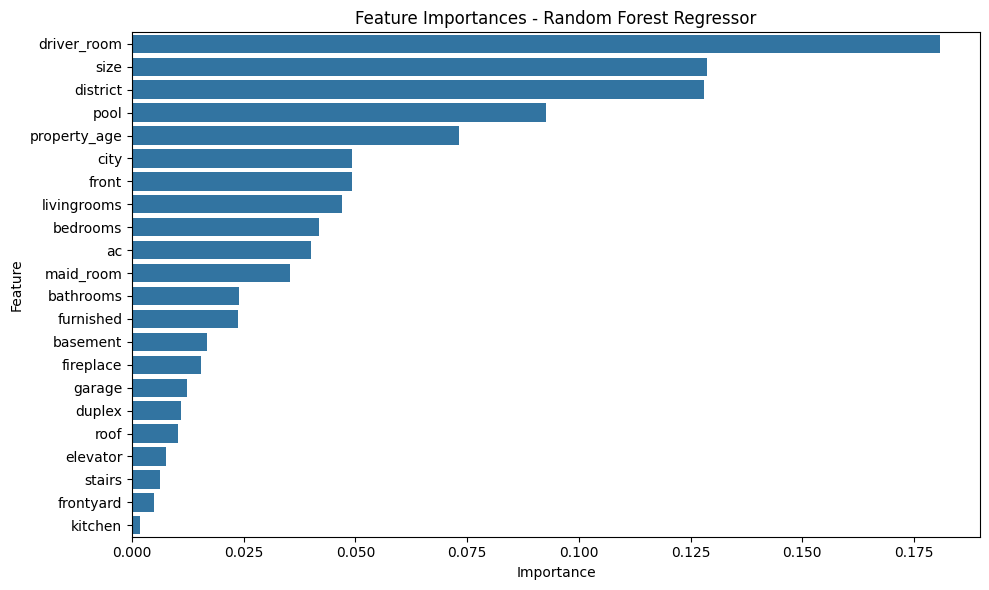

In [ ]:
importances = regressor.feature_importances_
feat_names = X_train.columns
feat_imp_df = pd.DataFrame({"Feature": feat_names, "Importance": importances}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp_df, x="Importance", y="Feature")
plt.title("Feature Importances - Random Forest Regressor")
plt.tight_layout()
plt.show()

# 12. Actual vs. Predicted Prices Plot

* Scatter plot comparing real vs. predicted house prices.

* Ideal performance aligns on the diagonal line.

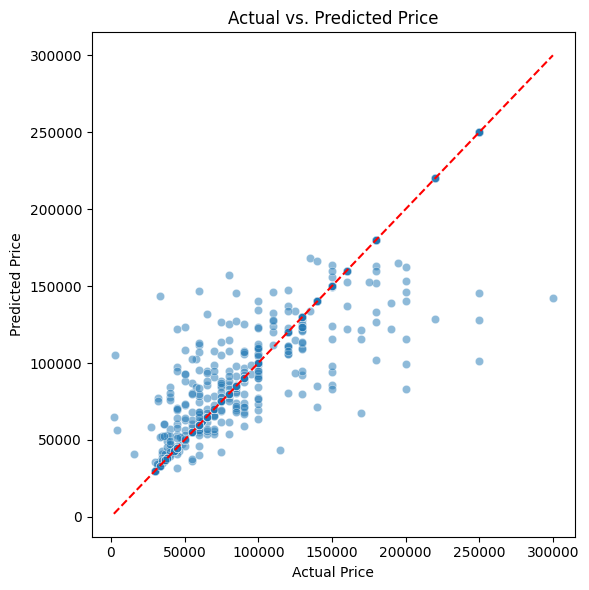

In [ ]:
preds = regressor.predict(X_test)
plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_reg_test, y=preds, alpha=0.5)
plt.plot([y_reg_test.min(), y_reg_test.max()], [y_reg_test.min(), y_reg_test.max()], 'r--')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs. Predicted Price")
plt.tight_layout()
plt.show()

# 13. Confusion Matrix Plot

* Shows how well the classifier separated high- and low-price houses.

* Displays false positives and negatives.

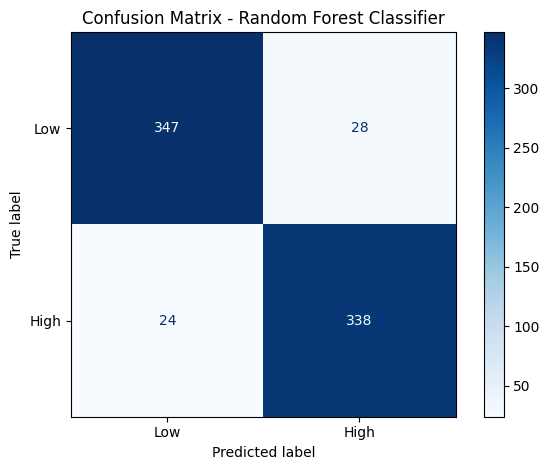

In [ ]:
y_pred_clf = classifier.predict(X_test)
cm = confusion_matrix(y_clf_test, y_pred_clf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Low", "High"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Random Forest Classifier")
plt.tight_layout()
plt.show()

# 14. Bar Charts for Model Comparison

Bar charts visually compare all models based on:

* RMSE (lower is better)

* R2 (higher is better)

* Accuracy and F1 Score for classification

<ipython-input-17-04d94b0186e5>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=reg_df, x="RMSE", y="Model", palette="Blues_d")
<ipython-input-17-04d94b0186e5>:5: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


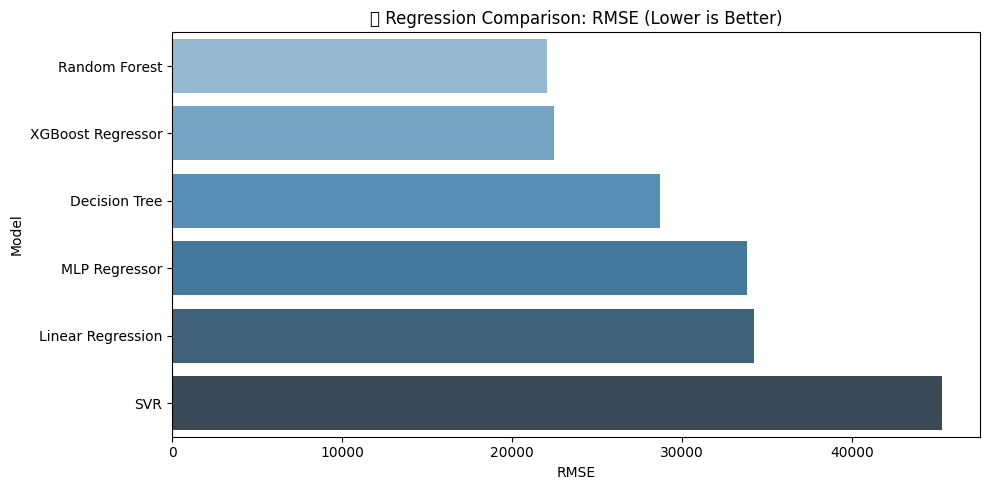

<ipython-input-17-04d94b0186e5>:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=reg_df, x="R2", y="Model", palette="Greens_d")


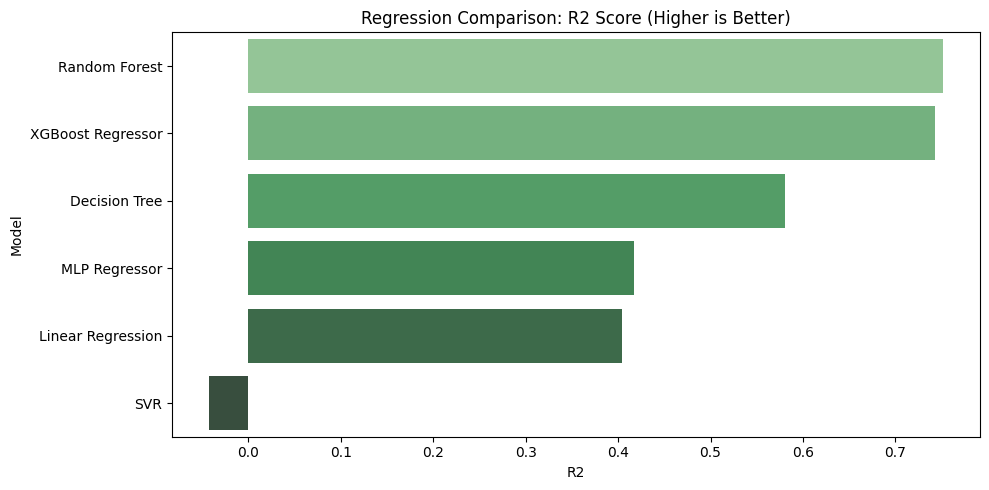

<ipython-input-17-04d94b0186e5>:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=clf_df, x="Accuracy", y="Model", palette="Purples_d")


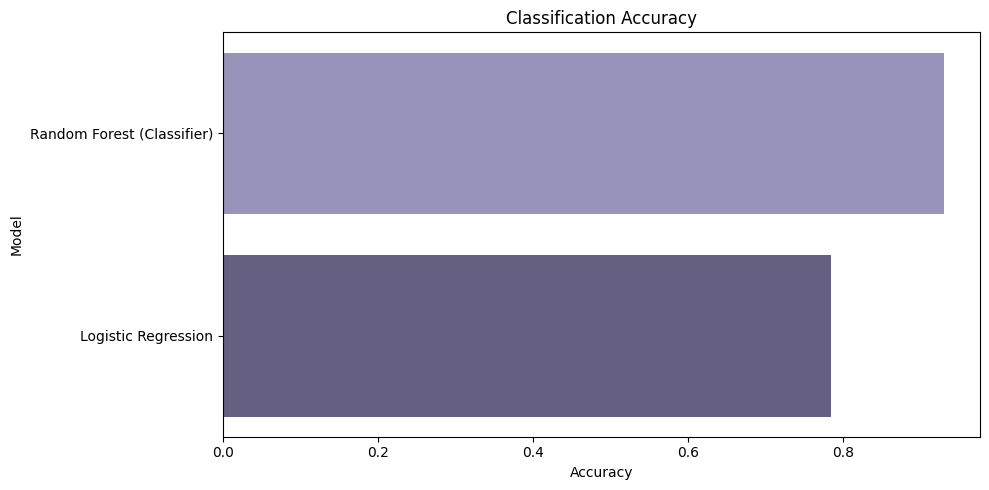

<ipython-input-17-04d94b0186e5>:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=clf_df, x="F1 Score", y="Model", palette="Oranges_d")


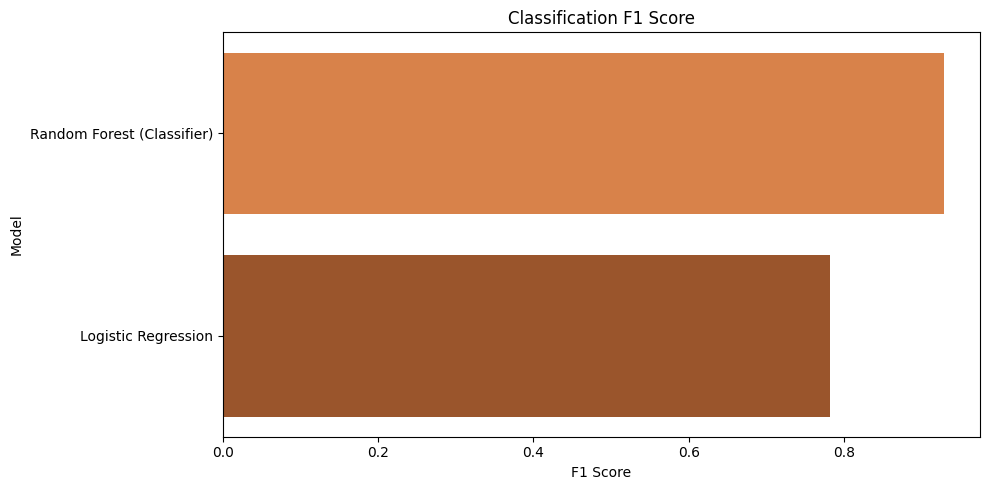

In [ ]:
# Regression RMSE
plt.figure(figsize=(10, 5))
sns.barplot(data=reg_df, x="RMSE", y="Model", palette="Blues_d")
plt.title("📉 Regression Comparison: RMSE (Lower is Better)")
plt.tight_layout()
plt.show()

# Regression R2
plt.figure(figsize=(10, 5))
sns.barplot(data=reg_df, x="R2", y="Model", palette="Greens_d")
plt.title("Regression Comparison: R2 Score (Higher is Better)")
plt.tight_layout()
plt.show()

# Classification Accuracy
plt.figure(figsize=(10, 5))
sns.barplot(data=clf_df, x="Accuracy", y="Model", palette="Purples_d")
plt.title("Classification Accuracy")
plt.tight_layout()
plt.show()

# Classification F1 Score
plt.figure(figsize=(10, 5))
sns.barplot(data=clf_df, x="F1 Score", y="Model", palette="Oranges_d")
plt.title("Classification F1 Score")
plt.tight_layout()
plt.show()